# Analise do dataset(altere o caminho para testar outros)

In [1]:
### Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
dataSetName = "Data_Lake Onego_V2.xlsx"
dataName = os.getcwd()+"/data/"+dataSetName
csv = pd.read_excel(dataName)
df = pd.DataFrame(csv)
df.head()


## https://www.google.com/url?sa=E&q=http%3A%2F%2Fdx.doi.org%2F10.17632%2Fk4f59fyhmy.1
"""Zobkov, Mikhail; Zobkova, Maria; alaGkhina, Natalia; Efremova, Tatiana; Efremenko, Natalia; Kulik, Natalia (2022), “Lake Onego water chemical composition based on seasonal field surveys in 2019-2021”, Mendeley Data, V1, doi: 10.17632/k4f59fyhmy.1"""

'Zobkov, Mikhail; Zobkova, Maria; alaGkhina, Natalia; Efremova, Tatiana; Efremenko, Natalia; Kulik, Natalia (2022), “Lake Onego water chemical composition based on seasonal field surveys in 2019-2021”, Mendeley Data, V1, doi: 10.17632/k4f59fyhmy.1'

In [ ]:

#Distribuição dos dados
df.hist(figsize=(20, 15));
plt.tight_layout();
plt.show();

In [ ]:
!pip install catboost
!pip install xgboost
!pip install sklearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [3]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
from xgboost import XGBRegressor 
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor

NameError: name 'XGBRegressor' is not defined

In [14]:
import xgboost
print(xgboost.__version__)

3.4.1


## Verificação de dados

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   N                   222 non-null    int64         
 1   Lake area           222 non-null    str           
 2   Station             222 non-null    str           
 3   Depth, m            222 non-null    float64       
 4   Date                222 non-null    datetime64[us]
 5   T, °C               208 non-null    float64       
 6   Latitude            222 non-null    float64       
 7   Longitude           222 non-null    float64       
 8   Cl-, mg/L           222 non-null    float64       
 9   Na+, mg/L           222 non-null    float64       
 10  EC, μS/сm at 25 °C  222 non-null    float64       
 11  рН                  222 non-null    float64       
 12  TSS, mg/L           222 non-null    object        
 13  Color, mg Pt-Co/L   222 non-null    float64       
 14  TOC, 

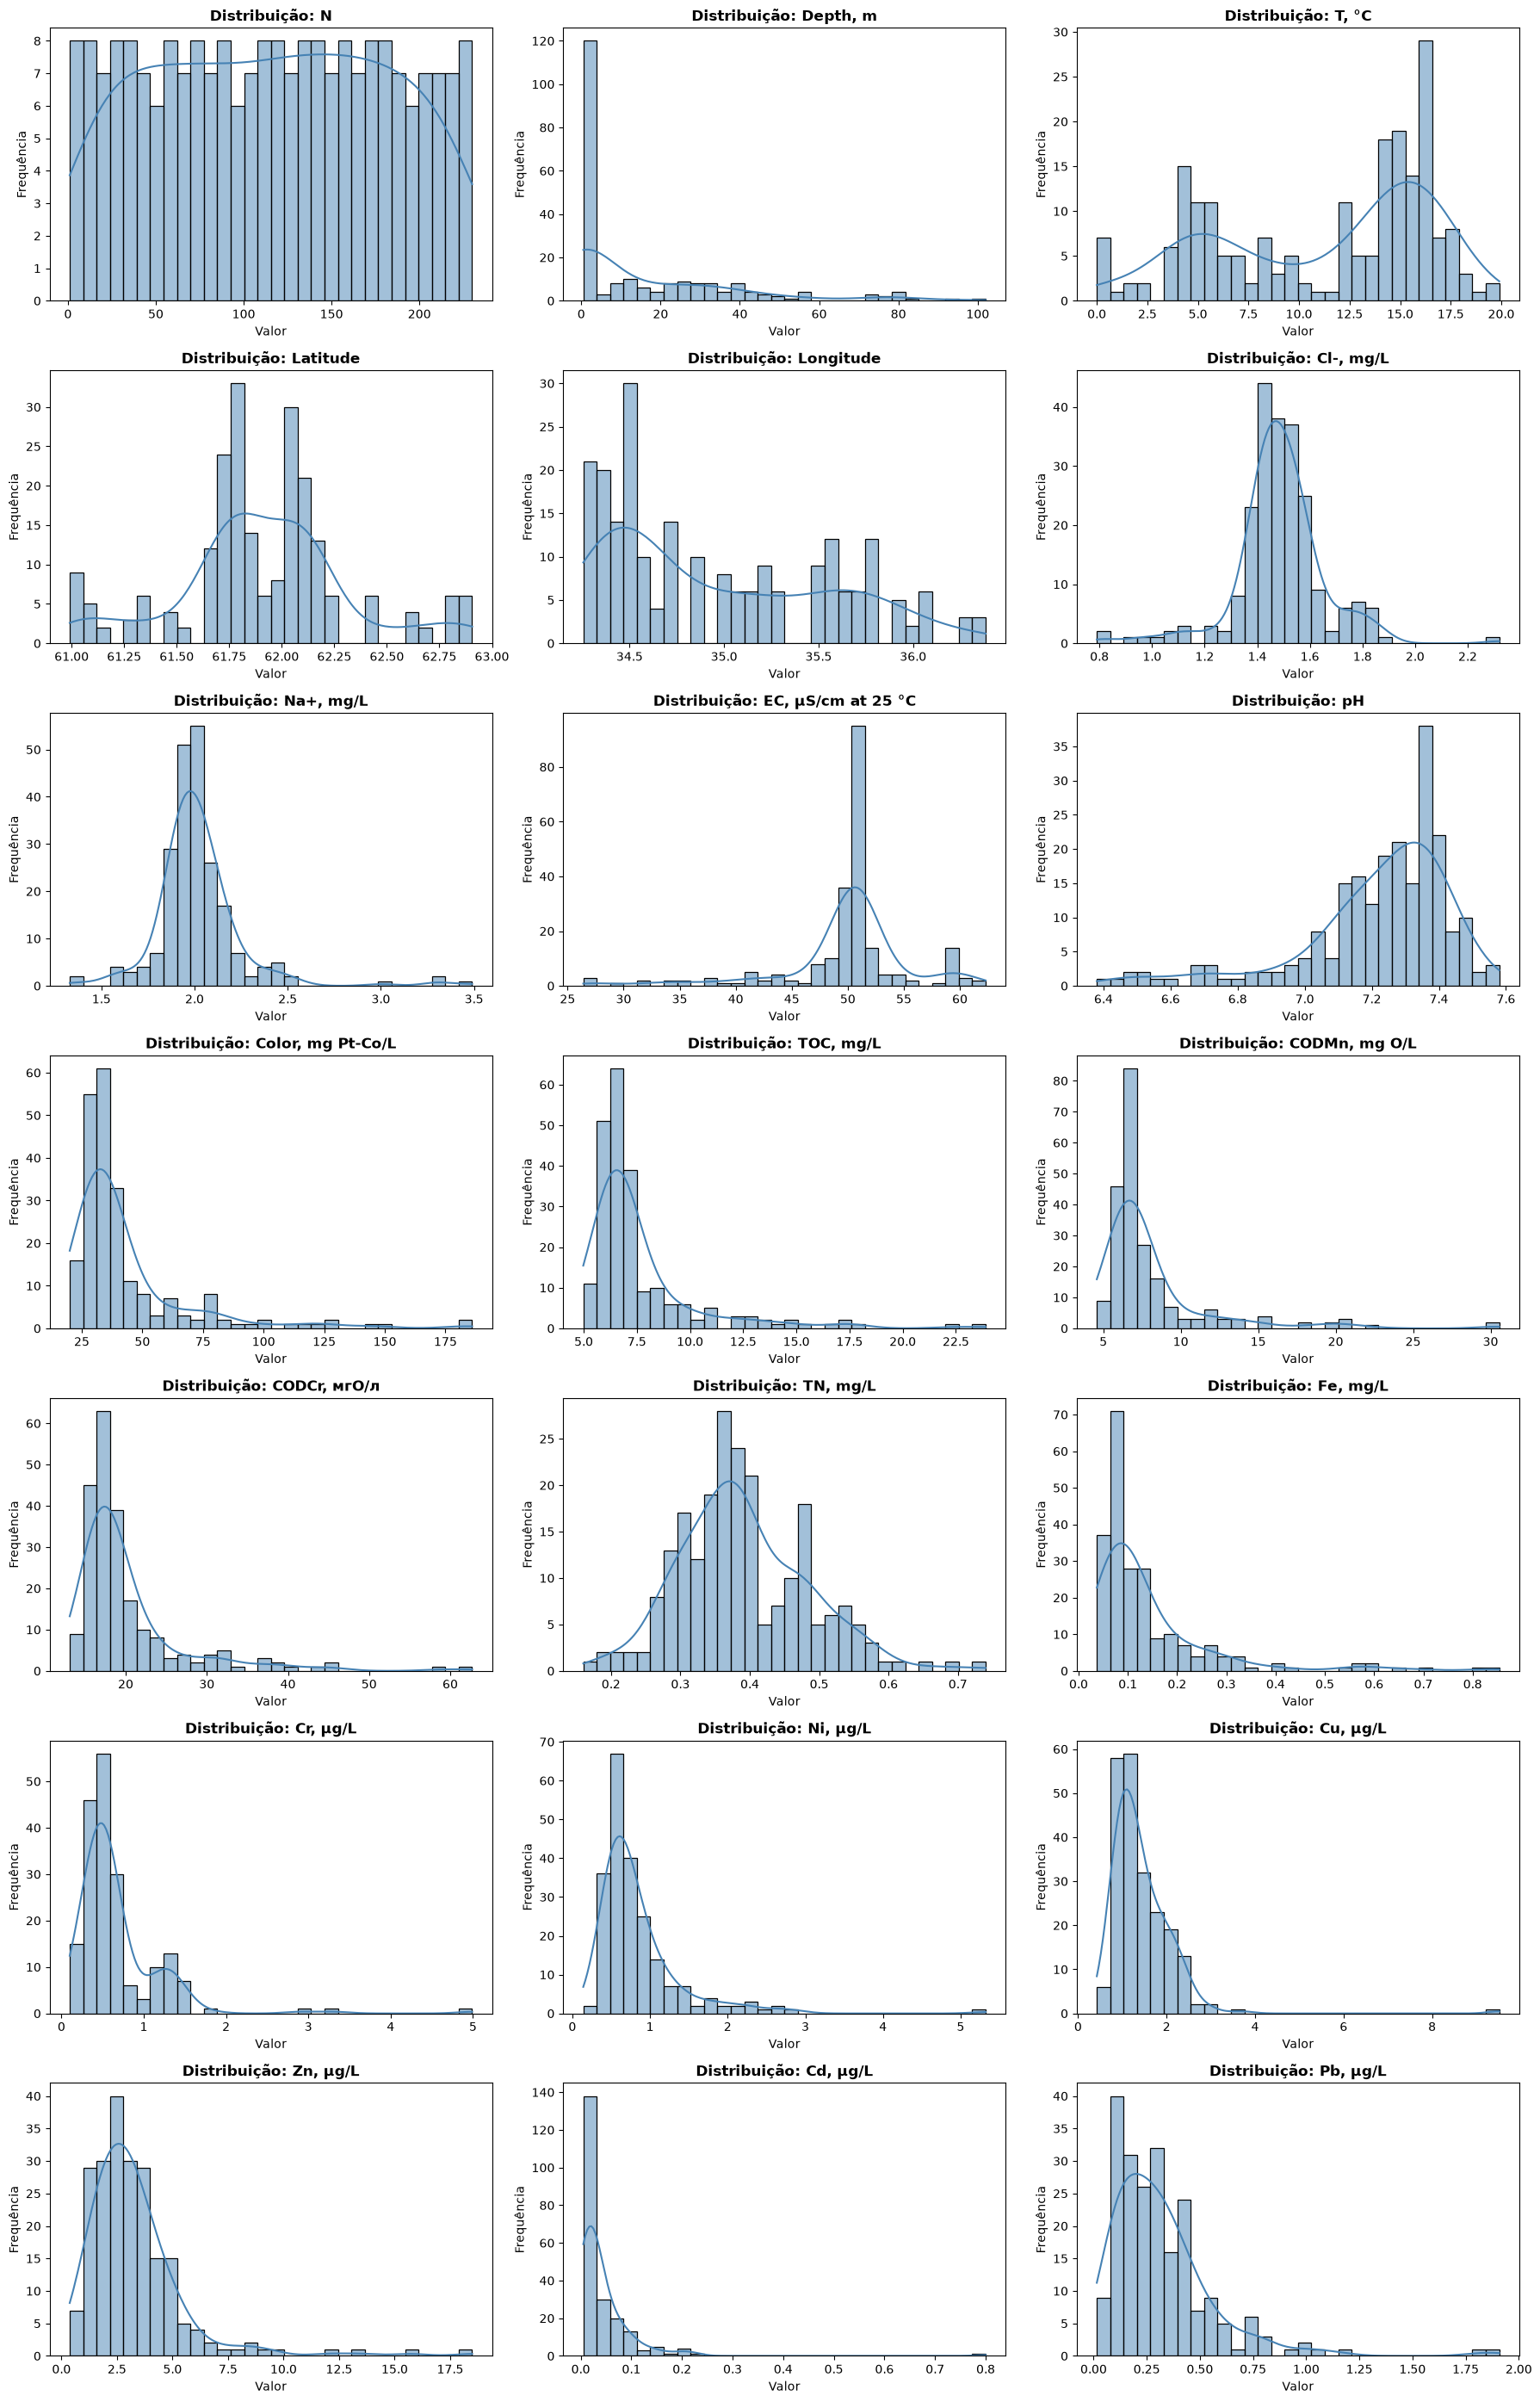

In [16]:
import math
# Limpar os espaços em branco nos nomes das colunas (problema identificado anteriormente)
df.columns = df.columns.str.strip()

# Selecionar apenas as variáveis numéricas
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns

# Definir o layout do grid de gráficos (3 colunas por linha)
num_cols = 3
num_rows = math.ceil(len(colunas_numericas) / num_cols)

# Configurar a figura principal
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 4 * num_rows))
axes = axes.flatten() # Achatar a matriz de eixos para facilitar o loop

# Plotar o histograma com a curva de densidade (KDE) para cada variável
for i, col in enumerate(colunas_numericas):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribuição: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')

# Remover os eixos sobressalentes caso o número de colunas não preencha o grid perfeitamente
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar o espaçamento e exibir
plt.tight_layout()
plt.show()

# Treinamento de modelo MultioutputRegressor

In [17]:
import re

def tratar_censurado(valor):
    if isinstance(valor, str) and valor.startswith("<"):
        limite = float(valor[1:])
        return limite / 2

    return float(valor)


In [21]:
#Definição de features e results(X,Y)
features = [
      "T, °C",
      "рН",
      "TSS, mg/L",
      "Color, mg Pt-Co/L",
      "TOC, mg/L",
      "CODMn, mg О/L",
      "CODCr, мгО/л",
      "BOD5, mg О2/L",
    "PO4-P, µg/L",
    "TP, µg/L",
    "NH4-N, mgN/L",
    "NO2-N, mgN/L",
    "NO3-N, mgN/L",
    "TN, mg/L",
    "EC, μS/сm at 25 °C",
    "Depth, m"
]


result = [
    "Fe, mg/L",
    "Mn, mg/L",
    "Cr, µg/L",
    "Ni, µg/L",
    "Cu, µg/L",
    "Zn, µg/L",
    "Cd, µg/L",
    "Pb, µg/L"
]
df[features] = df[features].map(tratar_censurado)
df[result] = df[result].map(tratar_censurado)

In [22]:
df.columns = df.columns.str.strip()
df = df.dropna()

X,Y = df.loc[:,features],df.loc[:,result]

In [25]:
TrainX,TestX,TrainY,TestY = train_test_split(X,Y,test_size=0.2,random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgboost = XGBRegressor(n_estimators=100, random_state=42)
catboost = CatBoostRegressor(iterations=100, random_state=42, verbose=0)

estimators = [
  ('rf',(rf)),
  ('xgboost',(xgboost)),
  ('catboost',(catboost))]

stackingModel = StackingRegressor(estimators=estimators, final_estimator=RidgeCV())
multiModels = MultiOutputRegressor(stackingModel)
multiModels.fit(TrainX,TrainY)



MultiOutputRegressor(estimator=StackingRegressor(estimators=[('rf',
                                                              RandomForestRegressor(random_state=42)),
                                                             ('xgboost',
                                                              XGBRegressor(base_score=None,
                                                                           booster=None,
                                                                           callbacks=None,
                                                                           colsample_bylevel=None,
                                                                           colsample_bynode=None,
                                                                           colsample_bytree=None,
                                                                           device=None,
                                                                           early_stopping_rounds=None,
                                                                           enable_categorical=True,
                                                                           eval_metric=None,
                                                                           feature_types=None,
                                                                           feature_w...
                                                                           max_cat_threshold=None,
                                                                           max_cat_to_onehot=None,
                                                                           max_delta_step=None,
                                                                           max_depth=None,
                                                                           max_leaves=None,
                                                                           min_child_weight=None,
                                                                           missing=nan,
                                                                           monotone_constraints=None,
                                                                           multi_strategy=None,
                                                                           n_estimators=100,
                                                                           n_jobs=None,
                                                                           num_parallel_tree=None, ...)),
                                                             ('catboost',
                                                              CatBoostRegressor(iterations=100, loss_function='RMSE', random_state=42, verbose=0))],
                                                 final_estimator=RidgeCV()))

In [29]:
results = multiModels.predict(TestX)
mse = mean_squared_error(TestY, results)
r2 = r2_score(TestY, results)
print("MSE:", mse)
print("R2:", r2)

MSE: 0.5432786415583443
R2: 0.12668626859819487


## Teste com apenas parametros fisicos-quimicos

In [ ]:
features = [
    "T, °C",
    "рН",
    "TSS, mg/L",
    "Color, mg Pt-Co/L",
    "TOC, mg/L",
    "CODMn, mg O/L",
    "CODCr, mgO/L",
    "BOD5, mg O2/L",
    "EC, μS/cm at 25 °C"
]
df



,N,Lake area,Station,"Depth, m",Date,"T, °C",Latitude,Longitude,"Cl-, mg/L","Na+, mg/L",...,"NO3-N, mgN/L","TN, mg/L","Fe, mg/L","Mn, mg/L","Cr, µg/L","Ni, µg/L","Cu, µg/L","Zn, µg/L","Cd, µg/L","Pb, µg/L"
0,1,South Onego,S5,0.5,2019-09-04,16.3,60.990889,35.500556,1.56,2.16,...,0.135,0.27,0.058,<0.01,1.240000,0.800000,2.010000,3.570000,0.090000,0.260000
1,2,South Onego,S4,0.5,2019-09-04,15.6,61.017333,35.797722,1.57,2.22,...,0.168,0.36,0.044,<0.01,1.260000,1.020000,2.380000,2.930000,0.040000,0.290000
3,4,South Onego,S3,0.5,2019-09-04,15.2,61.117028,35.932806,1.56,2.10,...,0.145,0.31,0.038,<0.01,1.180000,1.380000,2.190000,5.160000,0.020000,0.260000
4,5,South Onego,S3,28.0,2019-09-04,7.5,61.117028,35.932806,1.57,2.08,...,0.26,0.30,0.058,<0.01,1.050000,0.860000,2.110000,2.010000,0.040000,0.090000
5,6,Vytegra (estuarine area),VT,0.5,2019-09-04,16.0,61.103917,36.278278,1.55,2.11,...,0.129,0.36,0.114,<0.01,1.110000,0.840000,1.920000,1.900000,0.050000,0.130000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,198,Kizhi,Z3,0.5,2020-08-20,17.5,62.100194,35.251278,1.49,1.97,...,0.036,0.19,0.060,<0.01,0.564196,1.361181,1.068166,2.610992,0.027123,0.166985
192,199,Kizhi,Z3,9.0,2020-08-20,16.4,62.100194,35.251278,1.46,1.95,...,0.098,0.26,0.080,0.02,0.638605,5.322653,3.699116,5.610000,0.222143,0.765408
193,200,Kizhi,Z2,0.5,2020-08-20,18.0,62.076444,35.214278,1.51,2.02,...,<0.003,0.21,0.100,0.019,0.900470,1.946416,2.305887,4.130200,0.049342,0.427814
194,201,Kizhi,Z4,0.5,2020-08-20,18.2,62.025556,35.218639,1.50,2.02,...,0.003,0.21,0.070,0.01,0.638204,1.688545,1.698916,4.865511,0.215139,0.320279


In [ ]:
df.columns = df.columns.str.strip()
df = df.dropna()

X,Y = df.loc[:,features],df.loc[:,result]

KeyError: "['CODMn, mg O/L', 'CODCr, mgO/L', 'BOD5, mg O2/L', 'EC, μS/cm at 25 °C'] not in index"

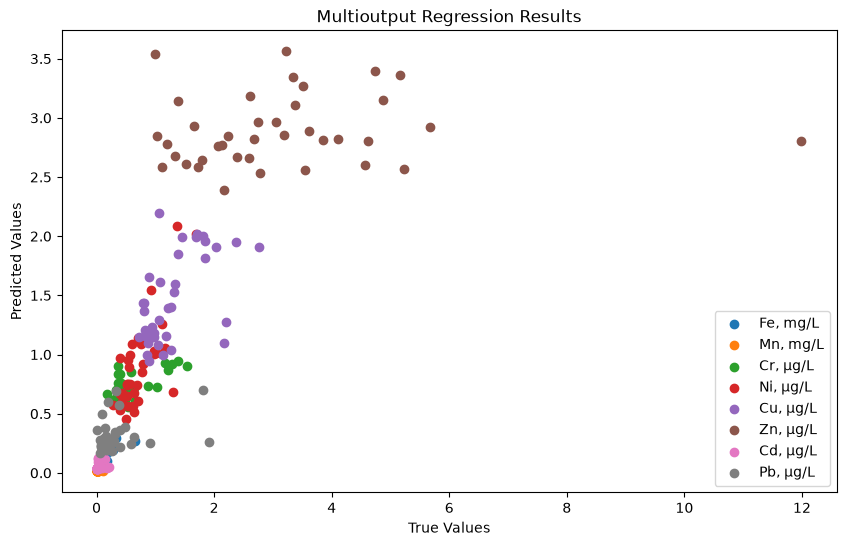

In [30]:
plt.figure(figsize=(10, 6))

for r in result:
  plt.scatter(TestY[r], results[:, result.index(r)], label=r)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Multioutput Regression Results')
plt.legend()
plt.show()

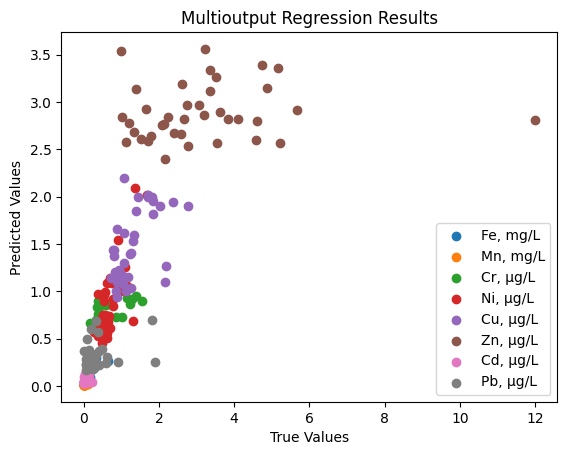

In [ ]:
XTrain,XTest,YTrain,YTest = train_test_split(X,Y,test_size=0.2,random_state=42)
multiModels.fit(XTrain,YTrain)
results = multiModels.predict(XTest)
for r in result:
  plt.scatter(YTest[r], results[:, result.index(r)], label=r)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Multioutput Regression Results')
plt.legend()
plt.show()

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor
from scipy.stats import randint, uniform

# 1. Definir os modelos base com regularização mais forte
rf = RandomForestRegressor(random_state=42)
xgboost = XGBRegressor(random_state=42)
catboost = CatBoostRegressor(verbose=0, random_state=42)

estimators = [
  ('rf', rf),
  ('xgboost', xgboost),
  ('catboost', catboost)
]

stackingModel = StackingRegressor(estimators=estimators, final_estimator=RidgeCV())
multiModels = MultiOutputRegressor(stackingModel)

# 2. Definir o espaço de busca de hiperparâmetros
# Foco em limitar a profundidade das árvores e diminuir a taxa de aprendizado (learning_rate)
param_distributions = {
    # Random Forest
    'estimator__rf__n_estimators': [50, 100, 200],
    'estimator__rf__max_depth': [3, 5, 8, 10],
    'estimator__rf__min_samples_leaf': [2, 5, 10],

    # XGBoost
    'estimator__xgboost__n_estimators': [50, 100],
    'estimator__xgboost__max_depth': [3, 5, 7],
    'estimator__xgboost__learning_rate': [0.01, 0.05, 0.1],
    'estimator__xgboost__subsample': [0.6, 0.8, 1.0],
    'estimator__xgboost__colsample_bytree': [0.6, 0.8, 1.0],

    # CatBoost
    'estimator__catboost__iterations': [50, 100, 200],
    'estimator__catboost__depth': [4, 6, 8],
    'estimator__catboost__learning_rate': [0.01, 0.05, 0.1],
    'estimator__catboost__l2_leaf_reg': [1, 3, 5, 10]
}

# 3. Configurar a busca (Randomized Search)
# n_iter=15 testa 15 combinações aleatórias para poupar tempo. Aumente se tiver poder computacional.
search = RandomizedSearchCV(
    estimator=multiModels,
    param_distributions=param_distributions,
    n_iter=15,
    scoring='r2',
    cv=3,           # Cross-validation com 3 folds
    random_state=42,
    n_jobs=-1,      # Usa todos os núcleos do processador
    verbose=2
)

# 4. Treinar a busca
search.fit(TrainX, TrainY)

print("Melhor R2 encontrado na validação cruzada:", search.best_score_)
print("Melhores parâmetros:", search.best_params_)

# 5. Avaliar no conjunto de teste
best_model = search.best_estimator_
score_teste = best_model.score(TestX, TestY)
print("R2 no conjunto de Teste:", score_teste)
#Melhores parâmetros: {'estimator__xgboost__subsample': 0.6, 'estimator__xgboost__n_estimators': 50, 'estimator__xgboost__max_depth': 3, 'estimator__xgboost__learning_rate': 0.05, 'estimator__xgboost__colsample_bytree': 0.6, 'estimator__rf__n_estimators': 50, 'estimator__rf__min_samples_leaf': 2, 'estimator__rf__max_depth': 3, 'estimator__catboost__learning_rate': 0.01, 'estimator__catboost__l2_leaf_reg': 3, 'estimator__catboost__iterations': 100, 'estimator__catboost__depth': 4

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Melhor R2 encontrado na validação cruzada: 0.18532439641031404
Melhores parâmetros: {'estimator__xgboost__subsample': 0.8, 'estimator__xgboost__n_estimators': 100, 'estimator__xgboost__max_depth': 5, 'estimator__xgboost__learning_rate': 0.01, 'estimator__xgboost__colsample_bytree': 0.8, 'estimator__rf__n_estimators': 100, 'estimator__rf__min_samples_leaf': 5, 'estimator__rf__max_depth': 8, 'estimator__catboost__learning_rate': 0.05, 'estimator__catboost__l2_leaf_reg': 10, 'estimator__catboost__iterations': 100, 'estimator__catboost__depth': 4}
R2 no conjunto de Teste: 0.13072258278411295


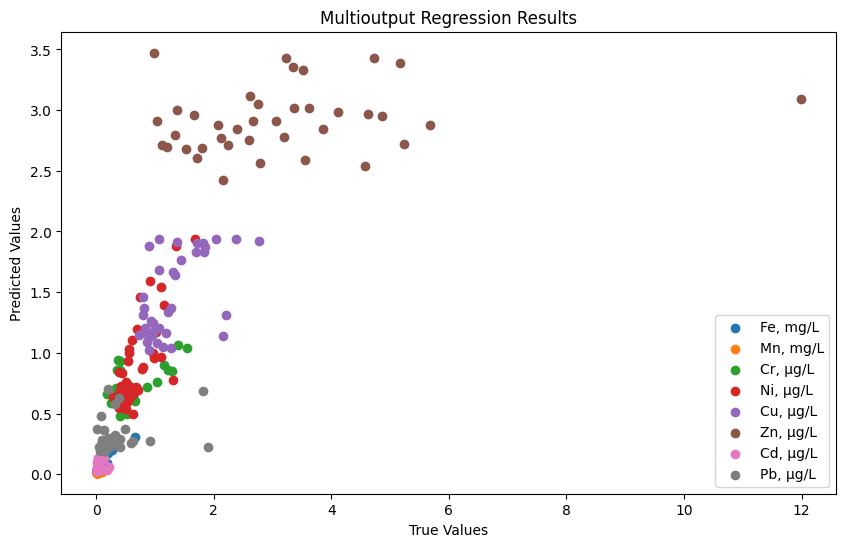

In [ ]:
plt.figure(figsize=(10, 6))
best_model.fit(TrainX, TrainY)
results = best_model.predict(TestX)
for r in result:
  plt.scatter(TestY[r], results[:, result.index(r)], label=r)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Multioutput Regression Results')
plt.legend()
plt.show()

#Download do modelo

In [ ]:
!pip install joblib

In [32]:
import os
import joblib
print(os.getcwd())
dir_path = os.getcwd()+"/model"
os.makedirs(dir_path, exist_ok=True)
file_path = os.path.join(dir_path, "best_model.pkl")
joblib.dump(best_model, file_path)

print(f"Modelo salvo com sucesso em: {file_path}")

c:\Users\lf446\OneDrive\Documentos\GitHub\WaterPath_TCC\back-end\ia\app\services\Predict
Modelo salvo com sucesso em: c:\Users\lf446\OneDrive\Documentos\GitHub\WaterPath_TCC\back-end\ia\app\services\Predict/model\best_model.pkl


In [ ]:
import xgboost

print(xgboost.__version__)

3.4.1


In [ ]:
import catboost
print(f"CatBoost version: {catboost.__version__}")

CatBoost version: 1.2.10


In [ ]:
import sklearn
print(f"Scikit-learn version: {sklearn.__version__}")

Scikit-learn version: 1.6.1


In [ ]:
import joblib
print(joblib.__version__)

1.5.3
